In [1]:
# PART 1 — INSTALL PACKAGES + IMPORTS

import sys
import subprocess
import importlib.util

packages = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost"
}

for module, package in packages.items():

    if importlib.util.find_spec(module) is None:

        print(f"Installing {package}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])

# IMPORTS

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("\n✓ Imports completed.")

Installing catboost...
TensorFlow: 2.20.0

✓ Imports completed.


In [2]:
# PART 2 — UPLOAD + LOAD CSV

from google.colab import files

print("=" * 80)
print("UPLOAD FINAL MERGED CSV")
print("=" * 80)

uploaded = files.upload()

csv_files = [
    f for f in uploaded.keys()
    if f.lower().endswith(".csv")
]

if len(csv_files) != 1:
    raise ValueError(
        f"Please upload exactly ONE CSV file. "
        f"Found {len(csv_files)} CSV files."
    )

FILE = csv_files[0]

print("\nUploaded:")
print(FILE)

# LOAD DATA

df = pd.read_csv(FILE)

print("\n")
print("=" * 80)
print("DATA INFORMATION")
print("=" * 80)

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

print(
    "Stations:",
    df["Station_ID"].nunique()
)

print(
    "Date range:",
    df["Date"].min(),
    "→",
    df["Date"].max()
)

UPLOAD FINAL MERGED CSV


Saving bangladesh_weather_stations_FINAL.csv to bangladesh_weather_stations_FINAL.csv

Uploaded:
bangladesh_weather_stations_FINAL.csv


DATA INFORMATION
Rows: 124,202
Columns: 22
Stations: 34
Date range: 2016-01-01 → 2025-12-31


In [3]:
# PART 3 — REQUIRED COLUMNS + DATE / DUPLICATE CLEANING

required_columns = [

    "Date",
    "Station_ID",

    "Latitude",
    "Longitude",

    "precipitation_sum",
    "rain_sum",

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",

    "apparent_temperature_mean",

    "sunshine_duration",
    "daylight_duration",

    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",

    "shortwave_radiation_sum",

    "weather_code",

    "et0_fao_evapotranspiration"
]

missing = [
    c for c in required_columns
    if c not in df.columns
]

if missing:

    raise ValueError(
        "Missing columns:\n" +
        str(missing)
    )

print("\n✓ All required columns found.")

# DATE CLEANING

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

if df["Date"].isna().any():

    raise ValueError(
        "Invalid Date values found."
    )

# SORT

df = (
    df
    .sort_values(
        ["Station_ID", "Date"]
    )
    .reset_index(drop=True)
)

# DUPLICATE CHECK

duplicates = df[
    df.duplicated(
        ["Station_ID", "Date"],
        keep=False
    )
]

if len(duplicates) > 0:

    display(
        duplicates.head(30)
    )

    raise ValueError(
        "Duplicate Station_ID + Date detected."
    )

print(
    "✓ No duplicate Station_ID + Date."
)


✓ All required columns found.
✓ No duplicate Station_ID + Date.


In [4]:
# PART 4 — TARGET CHECK + CALENDAR FEATURES

print("\n")
print("=" * 80)
print("TARGET DUPLICATE CHECK")
print("=" * 80)

corr = (
    df[
        [
            "rain_sum",
            "precipitation_sum"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

difference = (
    df["rain_sum"]
    -
    df["precipitation_sum"]
)

max_difference = (
    difference
    .abs()
    .max()
)

print(
    "Correlation:",
    corr
)

print(
    "Maximum absolute difference:",
    max_difference
)

if max_difference == 0:

    print(
        "\n✓ precipitation_sum is EXACTLY "
        "identical to rain_sum."
    )

else:

    print(
        "\n⚠ precipitation_sum is not exactly identical."
    )

# CLEAN TARGET

df.loc[
    df["rain_sum"] < 0,
    "rain_sum"
] = np.nan

before = len(df)

df = (
    df
    .dropna(
        subset=["rain_sum"]
    )
    .reset_index(drop=True)
)

print(
    "\nRemoved rows with invalid target:",
    before - len(df)
)

# SAME-DAY WEATHER FEATURES

same_day_weather = [

    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",

    "apparent_temperature_mean",

    "sunshine_duration",
    "daylight_duration",

    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",

    "shortwave_radiation_sum",

    "weather_code",

    "et0_fao_evapotranspiration"
]

print("\nSame-day weather features:")

for c in same_day_weather:
    print("✓", c)

# CALENDAR FEATURES

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofyear"] = df["Date"].dt.dayofyear
df["dayofweek"] = df["Date"].dt.dayofweek

df["weekofyear"] = (
    df["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

print("\n✓ Calendar features created.")



TARGET DUPLICATE CHECK
Correlation: 1.0
Maximum absolute difference: 0.0

✓ precipitation_sum is EXACTLY identical to rain_sum.

Removed rows with invalid target: 0

Same-day weather features:
✓ temperature_2m_mean
✓ temperature_2m_max
✓ temperature_2m_min
✓ apparent_temperature_mean
✓ sunshine_duration
✓ daylight_duration
✓ wind_speed_10m_max
✓ wind_gusts_10m_max
✓ wind_direction_10m_dominant
✓ shortwave_radiation_sum
✓ weather_code
✓ et0_fao_evapotranspiration

✓ Calendar features created.


In [5]:
# PART 5 — CYCLIC + RAINFALL FEATURES

# CYCLIC FEATURES

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["dayofyear_sin"] = np.sin(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["dayofyear_cos"] = np.cos(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["dayofweek_sin"] = np.sin(
    2 * np.pi * df["dayofweek"] / 7
)

df["dayofweek_cos"] = np.cos(
    2 * np.pi * df["dayofweek"] / 7
)

# RAINFALL LAGS

RAIN_LAGS = [
    1,
    2,
    3,
    5,
    7,
    14,
    21,
    30
]

for lag in RAIN_LAGS:

    df[
        f"rain_lag_{lag}"
    ] = (

        df
        .groupby(
            "Station_ID"
        )["rain_sum"]
        .shift(lag)

    )

# RAIN OCCURRENCE LAGS

rain_occurrence = (
    df["rain_sum"] > 0
).astype(int)

for lag in [
    1,
    2,
    3,
    7
]:

    df[
        f"rain_occurrence_lag_{lag}"
    ] = (

        rain_occurrence
        .groupby(
            df["Station_ID"]
        )
        .shift(lag)

    )


# RAINFALL ROLLING FEATURES


# shift(1) = ONLY previous rainfall.
# Current day's rainfall NEVER enters rolling calculation.

shifted_rain = (
    df
    .groupby(
        "Station_ID"
    )["rain_sum"]
    .shift(1)
)

for window in [
    3,
    7,
    14,
    30
]:

    grouped_rain = (
        shifted_rain
        .groupby(
            df["Station_ID"]
        )
    )

    df[
        f"rain_roll_mean_{window}"
    ] = (
        grouped_rain
        .transform(
            lambda x:
            x.rolling(
                window,
                min_periods=1
            ).mean()
        )
    )

    df[
        f"rain_roll_sum_{window}"
    ] = (
        grouped_rain
        .transform(
            lambda x:
            x.rolling(
                window,
                min_periods=1
            ).sum()
        )
    )

    df[
        f"rain_roll_std_{window}"
    ] = (
        grouped_rain
        .transform(
            lambda x:
            x.rolling(
                window,
                min_periods=2
            ).std()
        )
    )

print("✓ Cyclic features created.")
print("✓ Rainfall lag features created.")
print("✓ Rainfall rolling features created.")

✓ Cyclic features created.
✓ Rainfall lag features created.
✓ Rainfall rolling features created.


In [6]:
# PART 6 — WEATHER LAGS + STATION ENCODING + FEATURES


# PREVIOUS WEATHER LAGS

for feature in same_day_weather:

    for lag in [
        1,
        2,
        3,
        7
    ]:

        df[
            f"{feature}_lag_{lag}"
        ] = (

            df
            .groupby(
                "Station_ID"
            )[feature]
            .shift(lag)

        )

# STATION ENCODING

station_dummies = pd.get_dummies(
    df["Station_ID"],
    prefix="station",
    dtype=int
)

df = pd.concat(
    [
        df,
        station_dummies
    ],
    axis=1
)

# TARGET + LEAKAGE COLUMNS

TARGET = "rain_sum"

leakage_columns = [

    "rain_sum",
    "precipitation_sum",
    "precipitation_hours"
]

identifier_columns = [

    "Date",
    "Station_ID",
    "Division",
    "Station",
    "District"
]

columns_to_remove = list(
    dict.fromkeys(
        leakage_columns +
        identifier_columns
    )
)


# FEATURE LIST

feature_columns = [
    c
    for c in df.columns
    if c not in columns_to_remove
]


# HARD LEAKAGE CHECK

for bad_col in leakage_columns:

    if bad_col in feature_columns:

        raise ValueError(
            f"LEAKAGE DETECTED: {bad_col}"
        )


print("\n")
print("=" * 80)
print("LEAKAGE CHECK")
print("=" * 80)

print(
    "Target:",
    TARGET
)

print(
    "Number of features:",
    len(feature_columns)
)

print("\n✓ rain_sum removed")
print("✓ precipitation_sum removed")
print("✓ precipitation_hours removed")
print("✓ No random train/test split")
print("✓ Past rainfall features only")
print("✓ Same-day weather intentionally included")



LEAKAGE CHECK
Target: rain_sum
Number of features: 132

✓ rain_sum removed
✓ precipitation_sum removed
✓ precipitation_hours removed
✓ No random train/test split
✓ Past rainfall features only
✓ Same-day weather intentionally included


In [7]:

# PART 7 — BUILD X / y + TIME SPLIT

# BUILD X / y

X = df[
    feature_columns
].copy()

y = df[
    TARGET
].copy()


# TIME SPLIT

TRAIN_END = pd.Timestamp(
    "2022-12-31"
)

VAL_END = pd.Timestamp(
    "2024-12-31"
)

train_mask = (
    df["Date"] <= TRAIN_END
)

val_mask = (
    (df["Date"] > TRAIN_END)
    &
    (df["Date"] <= VAL_END)
)

test_mask = (
    df["Date"] > VAL_END
)


print("\n")
print("=" * 80)
print("TIME SPLIT")
print("=" * 80)

print(
    "TRAIN:",
    df.loc[
        train_mask,
        "Date"
    ].min(),
    "→",
    df.loc[
        train_mask,
        "Date"
    ].max()
)

print(
    "VALIDATION:",
    df.loc[
        val_mask,
        "Date"
    ].min(),
    "→",
    df.loc[
        val_mask,
        "Date"
    ].max()
)

print(
    "TEST:",
    df.loc[
        test_mask,
        "Date"
    ].min(),
    "→",
    df.loc[
        test_mask,
        "Date"
    ].max()
)

print(
    "\nTrain rows:",
    f"{train_mask.sum():,}"
)

print(
    "Validation rows:",
    f"{val_mask.sum():,}"
)

print(
    "Test rows:",
    f"{test_mask.sum():,}"
)
# SPLIT X / y

X_train = X.loc[
    train_mask
].copy()

y_train = y.loc[
    train_mask
].copy()

X_val = X.loc[
    val_mask
].copy()

y_val = y.loc[
    val_mask
].copy()

X_test = X.loc[
    test_mask
].copy()

y_test = y.loc[
    test_mask
].copy()

print("\n✓ Time split completed.")



TIME SPLIT
TRAIN: 2016-01-01 00:00:00 → 2022-12-31 00:00:00
VALIDATION: 2023-01-01 00:00:00 → 2024-12-31 00:00:00
TEST: 2025-01-01 00:00:00 → 2025-12-31 00:00:00

Train rows: 86,938
Validation rows: 24,854
Test rows: 12,410

✓ Time split completed.


In [8]:
# PART 8 — NUMERIC CLEANING + EVALUATION FUNCTION


# CONVERT EVERYTHING TO NUMERIC

for data_name, data in [
    ("X_train", X_train),
    ("X_val", X_val),
    ("X_test", X_test)
]:

    for col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# REPLACE INF

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_val = X_val.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

# TRAIN-ONLY MEDIAN IMPUTATION

train_medians = (
    X_train
    .median()
)

X_train = X_train.fillna(
    train_medians
)

X_val = X_val.fillna(
    train_medians
)

X_test = X_test.fillna(
    train_medians
)


# Final safeguard
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# FINAL TREE NaN / INF CHECK

for name, data in [
    ("X_train", X_train),
    ("X_val", X_val),
    ("X_test", X_test)
]:

    arr = data.to_numpy(
        dtype=np.float64
    )

    if not np.isfinite(arr).all():

        raise ValueError(
            f"{name} still contains NaN/Inf."
        )

print("\n✓ TRAIN/VAL/TEST contain NO NaN or Inf.")

# TARGET CHECK

for name, target in [
    ("y_train", y_train),
    ("y_val", y_val),
    ("y_test", y_test)
]:

    arr = target.to_numpy(
        dtype=np.float64
    )

    if not np.isfinite(arr).all():

        raise ValueError(
            f"{name} contains NaN/Inf."
        )

# EVALUATION FUNCTION

def evaluate_predictions(
    y_true,
    prediction
):

    y_true = np.asarray(
        y_true
    ).reshape(-1)

    prediction = np.asarray(
        prediction
    ).reshape(-1)

    if not np.isfinite(
        y_true
    ).all():

        raise ValueError(
            "y_true contains NaN/Inf."
        )

    if not np.isfinite(
        prediction
    ).all():

        raise ValueError(
            "prediction contains NaN/Inf."
        )

    prediction = np.maximum(
        prediction,
        0
    )

    r2 = r2_score(
        y_true,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            prediction
        )
    )

    mae = mean_absolute_error(
        y_true,
        prediction
    )

    return r2, rmse, mae


print("✓ Cleaning completed.")
print("✓ Evaluation function ready.")


✓ TRAIN/VAL/TEST contain NO NaN or Inf.
✓ Cleaning completed.
✓ Evaluation function ready.


In [9]:
# PART 9 — CATBOOST NORMAL + LOG


model_results = []
trained_models = {}


# CATBOOST NORMAL

print("\n")
print("=" * 80)
print("CATBOOST — NORMAL TARGET")
print("=" * 80)

cat_normal = CatBoostRegressor(

    iterations=1500,

    learning_rate=0.03,

    depth=8,

    loss_function="RMSE",

    l2_leaf_reg=5,

    random_seed=42,

    verbose=False,

    thread_count=-1
)

cat_normal.fit(

    X_train,

    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    early_stopping_rounds=80,

    verbose=False
)

cat_val_pred = (
    cat_normal.predict(
        X_val
    )
)

cat_r2, cat_rmse, cat_mae = (
    evaluate_predictions(
        y_val,
        cat_val_pred
    )
)

print(
    f"Validation R²: {cat_r2:.6f}"
)

print(
    f"RMSE: {cat_rmse:.6f}"
)

print(
    f"MAE: {cat_mae:.6f}"
)

trained_models[
    "CatBoost_Normal"
] = cat_normal

model_results.append({

    "Model":
        "CatBoost_Normal",

    "Validation_R2":
        cat_r2,

    "Validation_RMSE":
        cat_rmse,

    "Validation_MAE":
        cat_mae
})


# CATBOOST LOG

print("\n")
print("=" * 80)
print("CATBOOST — LOG TARGET")
print("=" * 80)

cat_log = CatBoostRegressor(

    iterations=1500,

    learning_rate=0.03,

    depth=8,

    loss_function="RMSE",

    l2_leaf_reg=5,

    random_seed=42,

    verbose=False,

    thread_count=-1
)

cat_log.fit(

    X_train,

    np.log1p(y_train),

    eval_set=[
        (
            X_val,
            np.log1p(y_val)
        )
    ],

    early_stopping_rounds=80,

    verbose=False
)

cat_log_val_pred = np.expm1(
    cat_log.predict(X_val)
)

cat_log_r2, cat_log_rmse, cat_log_mae = (
    evaluate_predictions(
        y_val,
        cat_log_val_pred
    )
)

print(
    f"Validation R²: {cat_log_r2:.6f}"
)

print(
    f"RMSE: {cat_log_rmse:.6f}"
)

print(
    f"MAE: {cat_log_mae:.6f}"
)

trained_models[
    "CatBoost_Log"
] = cat_log

model_results.append({

    "Model":
        "CatBoost_Log",

    "Validation_R2":
        cat_log_r2,

    "Validation_RMSE":
        cat_log_rmse,

    "Validation_MAE":
        cat_log_mae
})

print("\n✓ CatBoost models completed.")



CATBOOST — NORMAL TARGET
Validation R²: 0.827311
RMSE: 5.835964
MAE: 1.804154


CATBOOST — LOG TARGET
Validation R²: 0.805127
RMSE: 6.199496
MAE: 1.735987

✓ CatBoost models completed.


In [10]:
# PART 10 — LIGHTGBM NORMAL + LOG

# LIGHTGBM NORMAL

print("\n")
print("=" * 80)
print("LIGHTGBM — NORMAL TARGET")
print("=" * 80)

lgb_normal = LGBMRegressor(

    n_estimators=1500,

    learning_rate=0.03,

    num_leaves=63,

    max_depth=-1,

    min_child_samples=30,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    objective="regression",

    random_state=42,

    n_jobs=-1,

    verbosity=-1
)

lgb_normal.fit(

    X_train,

    y_train,

    eval_set=[
        (X_val, y_val)
    ]
)

lgb_val_pred = (
    lgb_normal.predict(
        X_val
    )
)

lgb_r2, lgb_rmse, lgb_mae = (
    evaluate_predictions(
        y_val,
        lgb_val_pred
    )
)

print(
    f"Validation R²: {lgb_r2:.6f}"
)

print(
    f"RMSE: {lgb_rmse:.6f}"
)

print(
    f"MAE: {lgb_mae:.6f}"
)

trained_models[
    "LightGBM_Normal"
] = lgb_normal

model_results.append({

    "Model":
        "LightGBM_Normal",

    "Validation_R2":
        lgb_r2,

    "Validation_RMSE":
        lgb_rmse,

    "Validation_MAE":
        lgb_mae
})

# LIGHTGBM LOG

print("\n")
print("=" * 80)
print("LIGHTGBM — LOG TARGET")
print("=" * 80)

lgb_log = LGBMRegressor(

    n_estimators=1500,

    learning_rate=0.03,

    num_leaves=63,

    max_depth=-1,

    min_child_samples=30,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    objective="regression",

    random_state=42,

    n_jobs=-1,

    verbosity=-1
)

lgb_log.fit(

    X_train,

    np.log1p(y_train),

    eval_set=[
        (
            X_val,
            np.log1p(y_val)
        )
    ]
)

lgb_log_val_pred = np.expm1(
    lgb_log.predict(X_val)
)

lgb_log_r2, lgb_log_rmse, lgb_log_mae = (
    evaluate_predictions(
        y_val,
        lgb_log_val_pred
    )
)

print(
    f"Validation R²: {lgb_log_r2:.6f}"
)

print(
    f"RMSE: {lgb_log_rmse:.6f}"
)

print(
    f"MAE: {lgb_log_mae:.6f}"
)

trained_models[
    "LightGBM_Log"
] = lgb_log

model_results.append({

    "Model":
        "LightGBM_Log",

    "Validation_R2":
        lgb_log_r2,

    "Validation_RMSE":
        lgb_log_rmse,

    "Validation_MAE":
        lgb_log_mae
})

print("\n✓ LightGBM models completed.")



LIGHTGBM — NORMAL TARGET
Validation R²: 0.818854
RMSE: 5.977162
MAE: 1.842219


LIGHTGBM — LOG TARGET
Validation R²: 0.809580
RMSE: 6.128256
MAE: 1.724083

✓ LightGBM models completed.


In [11]:
# PART 11 — XGBOOST + TREE MODEL COMPARISON

# XGBOOST NORMAL

print("\n")
print("=" * 80)
print("XGBOOST — NORMAL TARGET")
print("=" * 80)

xgb_normal = XGBRegressor(

    n_estimators=1500,

    learning_rate=0.03,

    max_depth=8,

    min_child_weight=5,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    objective="reg:squarederror",

    eval_metric="rmse",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

xgb_normal.fit(

    X_train,

    y_train,

    eval_set=[
        (
            X_val,
            y_val
        )
    ],

    verbose=False
)

xgb_val_pred = (
    xgb_normal.predict(
        X_val
    )
)

xgb_r2, xgb_rmse, xgb_mae = (
    evaluate_predictions(
        y_val,
        xgb_val_pred
    )
)

print(
    f"Validation R²: {xgb_r2:.6f}"
)

print(
    f"RMSE: {xgb_rmse:.6f}"
)

print(
    f"MAE: {xgb_mae:.6f}"
)

trained_models[
    "XGBoost_Normal"
] = xgb_normal

model_results.append({

    "Model":
        "XGBoost_Normal",

    "Validation_R2":
        xgb_r2,

    "Validation_RMSE":
        xgb_rmse,

    "Validation_MAE":
        xgb_mae
})

# XGBOOST LOG

print("\n")
print("=" * 80)
print("XGBOOST — LOG TARGET")
print("=" * 80)

xgb_log = XGBRegressor(

    n_estimators=1500,

    learning_rate=0.03,

    max_depth=8,

    min_child_weight=5,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    objective="reg:squarederror",

    eval_metric="rmse",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

xgb_log.fit(

    X_train,

    np.log1p(y_train),

    eval_set=[
        (
            X_val,
            np.log1p(y_val)
        )
    ],

    verbose=False
)

xgb_log_val_pred = np.expm1(
    xgb_log.predict(X_val)
)

xgb_log_r2, xgb_log_rmse, xgb_log_mae = (
    evaluate_predictions(
        y_val,
        xgb_log_val_pred
    )
)

print(
    f"Validation R²: {xgb_log_r2:.6f}"
)

print(
    f"RMSE: {xgb_log_rmse:.6f}"
)

print(
    f"MAE: {xgb_log_mae:.6f}"
)

trained_models[
    "XGBoost_Log"
] = xgb_log

model_results.append({

    "Model":
        "XGBoost_Log",

    "Validation_R2":
        xgb_log_r2,

    "Validation_RMSE":
        xgb_log_rmse,

    "Validation_MAE":
        xgb_log_mae
})
# TREE MODEL COMPARISON

tree_results = pd.DataFrame(
    model_results
)

tree_results = (
    tree_results
    .sort_values(
        "Validation_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 80)
print("TREE MODEL COMPARISON")
print("=" * 80)

display(
    tree_results
)

print("\n✓ All tree models completed.")



XGBOOST — NORMAL TARGET
Validation R²: 0.818538
RMSE: 5.982380
MAE: 1.852222


XGBOOST — LOG TARGET
Validation R²: 0.799928
RMSE: 6.281656
MAE: 1.744450


TREE MODEL COMPARISON


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,CatBoost_Normal,0.827311,5.835964,1.804154
1,LightGBM_Normal,0.818854,5.977162,1.842219
2,XGBoost_Normal,0.818538,5.982380,1.852222
3,LightGBM_Log,0.809580,6.128256,1.724083
4,CatBoost_Log,0.805127,6.199496,1.735987
5,XGBoost_Log,0.799928,6.281656,1.744450



✓ All tree models completed.


In [12]:
# PART 12 — LSTM PREPARATION + CLEANING

print("\n")
print("=" * 80)
print("LSTM PREPARATION — NaN SAFE")
print("=" * 80)

SEQUENCE_LENGTH = 30



# CRITICAL LSTM CLEANING

# X_lstm_all is cleaned BEFORE scaling.
# Training medians are used.

X_lstm_all = X.copy()

X_lstm_all = X_lstm_all.replace(
    [np.inf, -np.inf],
    np.nan
)


# TRAINING MEDIANS ONLY

lstm_train_medians = (
    X_lstm_all
    .loc[train_mask]
    .median()
)

X_lstm_all = (
    X_lstm_all
    .fillna(
        lstm_train_medians
    )
)


# FINAL SAFEGUARD
X_lstm_all = (
    X_lstm_all
    .fillna(0)
)


# FINAL LSTM INPUT CHECK

X_lstm_array = X_lstm_all.to_numpy(
    dtype=np.float32
)

if not np.isfinite(
    X_lstm_array
).all():

    raise ValueError(
        "LSTM input still contains NaN/Inf."
    )

print(
    "✓ LSTM input contains NO NaN/Inf."
)



# LSTM SCALER

# FIT ONLY ON TRAINING DATA


lstm_scaler = StandardScaler()

lstm_scaler.fit(
    X_lstm_array[
        train_mask.to_numpy()
    ]
)

X_all_scaled = (
    lstm_scaler
    .transform(
        X_lstm_array
    )
    .astype(
        np.float32
    )
)

if not np.isfinite(
    X_all_scaled
).all():

    raise ValueError(
        "Scaled LSTM data contains NaN/Inf."
    )

print(
    "✓ LSTM scaler fitted on TRAIN only."
)



LSTM PREPARATION — NaN SAFE
✓ LSTM input contains NO NaN/Inf.
✓ LSTM scaler fitted on TRAIN only.


In [13]:
# PART 13 — LSTM SEQUENCE FUNCTION


def create_lstm_sequences_safe(
    data_scaled,
    source_df,
    sequence_length,
    train_end,
    val_end
):

    X_train_seq = []
    y_train_seq = []

    X_val_seq = []
    y_val_seq = []

    X_test_seq = []
    y_test_seq = []

    train_dates = []
    val_dates = []
    test_dates = []

    train_stations = []
    val_stations = []
    test_stations = []


    # STATION BY STATION

    for station_id, station_df in (
        source_df
        .groupby(
            "Station_ID",
            sort=False
        )
    ):

        station_df = (
            station_df
            .sort_values(
                "Date"
            )
        )

        indices = (
            station_df
            .index
            .to_numpy()
        )

        if len(indices) <= sequence_length:
            continue


        # EACH TARGET GETS PREVIOUS 30 DAYS
        # PLUS TARGET-DAY WEATHER

        for pos in range(
            sequence_length,
            len(indices)
        ):

            target_idx = (
                indices[pos]
            )

            sequence_indices = (
                indices[
                    pos - sequence_length:
                    pos + 1
                ]
            )

            sequence = (
                data_scaled[
                    sequence_indices
                ]
            )

            target = float(
                source_df
                .loc[
                    target_idx,
                    "rain_sum"
                ]
            )

            target_date = (
                source_df
                .loc[
                    target_idx,
                    "Date"
                ]
            )



            # CRITICAL FINITE CHECK

            if not np.isfinite(
                sequence
            ).all():

                continue

            if not np.isfinite(
                target
            ):

                continue

            # TRAIN

            if target_date <= train_end:

                X_train_seq.append(
                    sequence
                )

                y_train_seq.append(
                    target
                )

                train_dates.append(
                    target_date
                )

                train_stations.append(
                    station_id
                )


            # VALIDATION

            elif target_date <= val_end:

                X_val_seq.append(
                    sequence
                )

                y_val_seq.append(
                    target
                )

                val_dates.append(
                    target_date
                )

                val_stations.append(
                    station_id
                )

            # TEST

            else:

                X_test_seq.append(
                    sequence
                )

                y_test_seq.append(
                    target
                )

                test_dates.append(
                    target_date
                )

                test_stations.append(
                    station_id
                )


    return (

        np.asarray(
            X_train_seq,
            dtype=np.float32
        ),

        np.asarray(
            y_train_seq,
            dtype=np.float32
        ),

        np.asarray(
            X_val_seq,
            dtype=np.float32
        ),

        np.asarray(
            y_val_seq,
            dtype=np.float32
        ),

        np.asarray(
            X_test_seq,
            dtype=np.float32
        ),

        np.asarray(
            y_test_seq,
            dtype=np.float32
        ),

        train_dates,
        val_dates,
        test_dates,

        train_stations,
        val_stations,
        test_stations
    )


print("✓ LSTM sequence function created.")

✓ LSTM sequence function created.


In [14]:
# PART 14 — CREATE LSTM SEQUENCES + CHECKS


(
    X_lstm_train,
    y_lstm_train,

    X_lstm_val,
    y_lstm_val,

    X_lstm_test,
    y_lstm_test,

    lstm_train_dates,
    lstm_val_dates,
    lstm_test_dates,

    lstm_train_stations,
    lstm_val_stations,
    lstm_test_stations

) = create_lstm_sequences_safe(

    X_all_scaled,

    df,

    SEQUENCE_LENGTH,

    TRAIN_END,

    VAL_END
)

# LSTM SHAPE CHECK

print("\nLSTM Train:")
print(X_lstm_train.shape)

print("\nLSTM Validation:")
print(X_lstm_val.shape)

print("\nLSTM Test:")
print(X_lstm_test.shape)


# FINAL LSTM NaN CHECK

for name, arr in [

    ("X_lstm_train", X_lstm_train),
    ("y_lstm_train", y_lstm_train),

    ("X_lstm_val", X_lstm_val),
    ("y_lstm_val", y_lstm_val),

    ("X_lstm_test", X_lstm_test),
    ("y_lstm_test", y_lstm_test)

]:

    if not np.isfinite(
        arr
    ).all():

        raise ValueError(
            f"{name} contains NaN/Inf."
        )


print(
    "\n✓ ALL LSTM ARRAYS ARE FINITE."
)

print("\n✓ LSTM sequences ready.")


LSTM Train:
(85918, 31, 132)

LSTM Validation:
(24854, 31, 132)

LSTM Test:
(12410, 31, 132)

✓ ALL LSTM ARRAYS ARE FINITE.

✓ LSTM sequences ready.


In [15]:
# PART 15 — LSTM NORMAL TARGET

print("\n")
print("=" * 80)
print("LSTM — NORMAL TARGET")
print("=" * 80)

tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

# MODEL

lstm_normal = Sequential([

    Input(
        shape=(
            X_lstm_train.shape[1],
            X_lstm_train.shape[2]
        )
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.20),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="linear"
    )
])

# COMPILE

lstm_normal.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),

    loss="mse",

    metrics=[
        "mae"
    ]
)

# CALLBACKS

normal_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


# TRAIN

history_normal = (
    lstm_normal.fit(

        X_lstm_train,

        y_lstm_train,

        validation_data=(
            X_lstm_val,
            y_lstm_val
        ),

        epochs=50,

        batch_size=256,

        callbacks=normal_callbacks,

        verbose=1
    )
)



# VALIDATION

lstm_normal_val_pred = (
    lstm_normal
    .predict(
        X_lstm_val,
        batch_size=1024,
        verbose=0
    )
    .reshape(-1)
)


if not np.isfinite(
    lstm_normal_val_pred
).all():

    raise ValueError(
        "LSTM Normal prediction contains NaN/Inf."
    )


lstm_normal_val_pred = np.maximum(
    lstm_normal_val_pred,
    0
)


(
    lstm_normal_r2,
    lstm_normal_rmse,
    lstm_normal_mae

) = evaluate_predictions(

    y_lstm_val,

    lstm_normal_val_pred
)


print(
    f"\nValidation R²: "
    f"{lstm_normal_r2:.6f}"
)

print(
    f"RMSE: "
    f"{lstm_normal_rmse:.6f}"
)

print(
    f"MAE: "
    f"{lstm_normal_mae:.6f}"
)

# STORE

trained_models[
    "LSTM_Normal"
] = lstm_normal

model_results.append({

    "Model":
        "LSTM_Normal",

    "Validation_R2":
        lstm_normal_r2,

    "Validation_RMSE":
        lstm_normal_rmse,

    "Validation_MAE":
        lstm_normal_mae
})

print("\n✓ LSTM Normal completed.")



LSTM — NORMAL TARGET
Epoch 1/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 113.7851 - mae: 4.7905 - val_loss: 121.4567 - val_mae: 3.7289 - learning_rate: 5.0000e-04
Epoch 2/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 63.2381 - mae: 3.3604 - val_loss: 87.6110 - val_mae: 3.1506 - learning_rate: 5.0000e-04
Epoch 3/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 50.2441 - mae: 3.0412 - val_loss: 76.5774 - val_mae: 2.9528 - learning_rate: 5.0000e-04
Epoch 4/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 44.9606 - mae: 2.8804 - val_loss: 69.9864 - val_mae: 2.8137 - learning_rate: 5.0000e-04
Epoch 5/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 41.0236 - mae: 2.7502 - val_loss: 66.2187 - val_mae: 2.7044 - learning_rate: 5.0000e-04
Epoch 6/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 38.4804 - mae: 2.6506 - val_loss: 67.0460 - val_mae: 2.6578 - learning_rate: 5.0000e-04
Epoch 7/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 35.8239 - mae: 2.53

In [16]:
# PART 16 — LSTM LOG TARGET

print("\n")
print("=" * 80)
print("LSTM — LOG TARGET")
print("=" * 80)

tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)


# MODEL

lstm_log = Sequential([

    Input(
        shape=(
            X_lstm_train.shape[1],
            X_lstm_train.shape[2]
        )
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.20),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="linear"
    )
])

# COMPILE

lstm_log.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),

    loss="mse",

    metrics=[
        "mae"
    ]
)

# CALLBACKS

log_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# TRAIN

history_log = (
    lstm_log.fit(

        X_lstm_train,

        np.log1p(
            y_lstm_train
        ),

        validation_data=(

            X_lstm_val,

            np.log1p(
                y_lstm_val
            )
        ),

        epochs=50,

        batch_size=256,

        callbacks=log_callbacks,

        verbose=1
    )
)
# VALIDATION

lstm_log_val_pred = (
    lstm_log
    .predict(
        X_lstm_val,
        batch_size=1024,
        verbose=0
    )
    .reshape(-1)
)


if not np.isfinite(
    lstm_log_val_pred
).all():

    raise ValueError(
        "LSTM Log prediction contains NaN/Inf."
    )


lstm_log_val_pred = np.expm1(
    lstm_log_val_pred
)

lstm_log_val_pred = np.maximum(
    lstm_log_val_pred,
    0
)


(
    lstm_log_r2,
    lstm_log_rmse,
    lstm_log_mae

) = evaluate_predictions(

    y_lstm_val,

    lstm_log_val_pred
)


print(
    f"\nValidation R²: "
    f"{lstm_log_r2:.6f}"
)

print(
    f"RMSE: "
    f"{lstm_log_rmse:.6f}"
)

print(
    f"MAE: "
    f"{lstm_log_mae:.6f}"
)

# STORE

trained_models[
    "LSTM_Log"
] = lstm_log

model_results.append({

    "Model":
        "LSTM_Log",

    "Validation_R2":
        lstm_log_r2,

    "Validation_RMSE":
        lstm_log_rmse,

    "Validation_MAE":
        lstm_log_mae
})

print("\n✓ LSTM Log completed.")



LSTM — LOG TARGET
Epoch 1/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.6318 - mae: 0.5445 - val_loss: 0.3065 - val_mae: 0.3656 - learning_rate: 5.0000e-04
Epoch 2/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2874 - mae: 0.3626 - val_loss: 0.2174 - val_mae: 0.2917 - learning_rate: 5.0000e-04
Epoch 3/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2166 - mae: 0.3029 - val_loss: 0.1680 - val_mae: 0.2488 - learning_rate: 5.0000e-04
Epoch 4/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1649 - mae: 0.2587 - val_loss: 0.1245 - val_mae: 0.2089 - learning_rate: 5.0000e-04
Epoch 5/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1337 - mae: 0.2311 - val_loss: 0.1059 - val_mae: 0.1935 - learning_rate: 5.0000e-04
Epoch 6/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1206 - mae: 0.2196 - val_loss: 0.0996 - val_mae: 0.1871 - learning_rate: 5.0000e-04
Epoch 7/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1117 - mae: 0.2121 - val_loss: 0.09

In [17]:
# PART 17 — FINAL MODEL RANKING + 2025 TEST


# FINAL MODEL RANKING

all_results = pd.DataFrame(
    model_results
)

all_results = (
    all_results
    .sort_values(
        "Validation_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 80)
print("FINAL MODEL RANKING")
print("=" * 80)

display(
    all_results
)


# BEST MODEL

BEST_MODEL = (
    all_results
    .iloc[0]["Model"]
)

BEST_VAL_R2 = (
    all_results
    .iloc[0]["Validation_R2"]
)

print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    "Best Model:",
    BEST_MODEL
)

print(
    "Validation R²:",
    f"{BEST_VAL_R2:.6f}"
)


# FINAL TEST PREDICTION

if BEST_MODEL == "CatBoost_Normal":

    test_pred = (
        cat_normal
        .predict(X_test)
    )

elif BEST_MODEL == "CatBoost_Log":

    test_pred = np.expm1(
        cat_log.predict(X_test)
    )

elif BEST_MODEL == "LightGBM_Normal":

    test_pred = (
        lgb_normal
        .predict(X_test)
    )

elif BEST_MODEL == "LightGBM_Log":

    test_pred = np.expm1(
        lgb_log.predict(X_test)
    )

elif BEST_MODEL == "XGBoost_Normal":

    test_pred = (
        xgb_normal
        .predict(X_test)
    )

elif BEST_MODEL == "XGBoost_Log":

    test_pred = np.expm1(
        xgb_log.predict(X_test)
    )

elif BEST_MODEL == "LSTM_Normal":

    test_pred = (
        lstm_normal
        .predict(
            X_lstm_test,
            batch_size=1024,
            verbose=0
        )
        .reshape(-1)
    )

elif BEST_MODEL == "LSTM_Log":

    test_pred = (
        lstm_log
        .predict(
            X_lstm_test,
            batch_size=1024,
            verbose=0
        )
        .reshape(-1)
    )

    test_pred = np.expm1(
        test_pred
    )

else:

    raise ValueError(
        f"Unknown model: {BEST_MODEL}"
    )



# FINAL TEST SAFETY

test_pred = np.asarray(
    test_pred
).reshape(-1)

test_pred = np.maximum(
    test_pred,
    0
)

if not np.isfinite(
    test_pred
).all():

    raise ValueError(
        "FINAL TEST prediction contains NaN/Inf."
    )


# FINAL TEST METRICS

if BEST_MODEL.startswith(
    "LSTM"
):

    final_y_test = (
        y_lstm_test
    )

else:

    final_y_test = (
        y_test.to_numpy()
    )


(
    test_r2,
    test_rmse,
    test_mae

) = evaluate_predictions(

    final_y_test,

    test_pred
)


# FINAL RESULT

print("\n")
print("=" * 80)
print("FINAL TEST PERFORMANCE — 2025")
print("=" * 80)

print(
    "Best Model:",
    BEST_MODEL
)

print(
    f"Validation R² : "
    f"{BEST_VAL_R2:.6f}"
)

print(
    f"Test R²       : "
    f"{test_r2:.6f}"
)

print(
    f"Test RMSE     : "
    f"{test_rmse:.6f}"
)

print(
    f"Test MAE      : "
    f"{test_mae:.6f}"
)



FINAL MODEL RANKING


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,CatBoost_Normal,0.827311,5.835964,1.804154
1,LightGBM_Normal,0.818854,5.977162,1.842219
2,XGBoost_Normal,0.818538,5.982380,1.852222
3,LightGBM_Log,0.809580,6.128256,1.724083
4,CatBoost_Log,0.805127,6.199496,1.735987
5,XGBoost_Log,0.799928,6.281656,1.744450
6,LSTM_Normal,0.725309,7.360429,2.272105
7,LSTM_Log,0.659738,8.191952,2.281469




BEST MODEL
Best Model: CatBoost_Normal
Validation R²: 0.827311


FINAL TEST PERFORMANCE — 2025
Best Model: CatBoost_Normal
Validation R² : 0.827311
Test R²       : 0.879588
Test RMSE     : 4.254902
Test MAE      : 1.720131




BEST MODEL PERFORMANCE


,Dataset,Model,R2,RMSE,MAE
0,Validation,CatBoost_Normal,0.827311,5.835964,1.804154
1,Test,CatBoost_Normal,0.879588,4.254902,1.720131


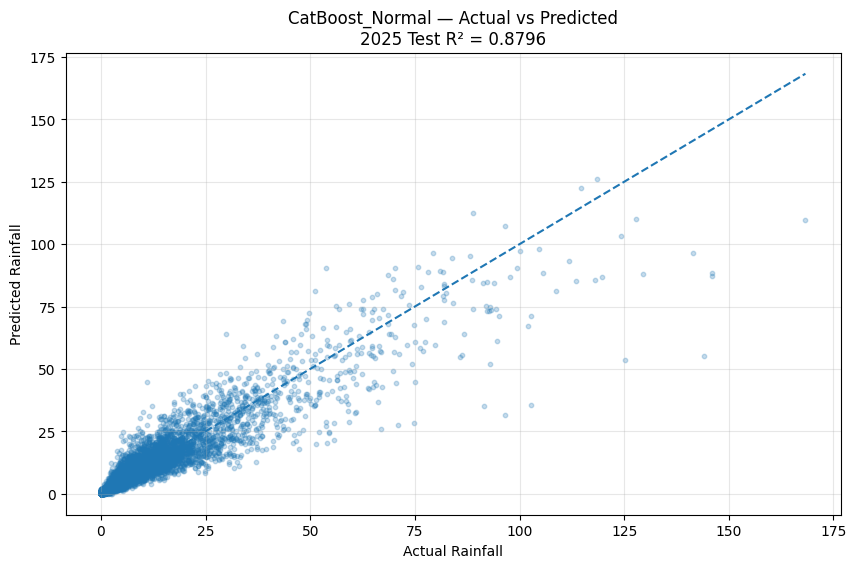

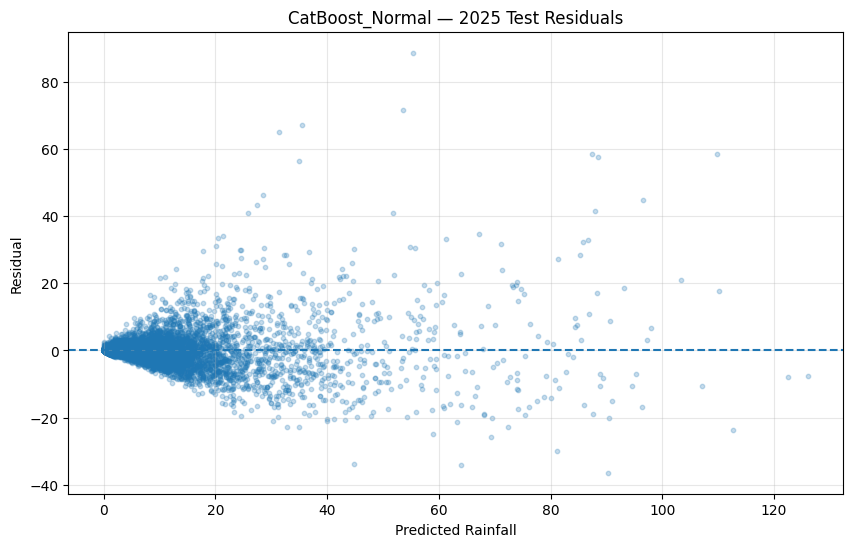



TOP 30 FEATURE IMPORTANCE


,Feature,Importance
0,weather_code,37.930134
1,shortwave_radiation_sum,10.731069
2,et0_fao_evapotranspiration,7.518483
3,sunshine_duration,4.176054
4,Longitude,3.639663
5,rain_lag_1,3.370013
6,wind_gusts_10m_max,3.090634
7,wind_speed_10m_max,2.566624
8,Latitude,2.097384
9,wind_direction_10m_dominant,1.575267




FINAL SUMMARY
Dataset rows: 124,202
Stations: 34
Features: 132

Train rows: 86,938
Validation rows: 24,854
Test rows: 12,410

Best Model: CatBoost_Normal
Validation R²: 0.827311
Test R²: 0.879588
Test RMSE: 4.254902
Test MAE: 1.720131


LEAKAGE / DATA QUALITY CHECKLIST
✓ Same-day weather features included
✓ rain_sum removed from features
✓ precipitation_sum removed
✓ precipitation_hours removed
✓ No random split
✓ Chronological Train / Validation / Test
✓ Past rainfall lags included
✓ Rain occurrence lags included
✓ Rolling rainfall uses shift(1)
✓ Previous weather lags included
✓ Train-only median imputation
✓ LSTM scaler fitted on TRAIN only
✓ LSTM NaN/Inf protection
✓ Normal vs Log rainfall compared
✓ CatBoost / LightGBM / XGBoost / LSTM compared
✓ Best model selected using Validation R²
✓ Final evaluation on untouched 2025 test set
✓ NO prediction CSV saved
✓ NO prediction CSV downloaded


DONE


In [18]:

# PART 18 — FINAL PERFORMANCE REPORT + PLOTS + IMPORTANCE

# PERFORMANCE TABLE

final_performance = pd.DataFrame({

    "Dataset": [
        "Validation",
        "Test"
    ],

    "Model": [
        BEST_MODEL,
        BEST_MODEL
    ],

    "R2": [
        BEST_VAL_R2,
        test_r2
    ],

    "RMSE": [

        all_results.iloc[0][
            "Validation_RMSE"
        ],

        test_rmse
    ],

    "MAE": [

        all_results.iloc[0][
            "Validation_MAE"
        ],

        test_mae
    ]
})


print("\n")
print("=" * 80)
print("BEST MODEL PERFORMANCE")
print("=" * 80)

display(
    final_performance
)


# ACTUAL VS PREDICTED

plot_df = pd.DataFrame({

    "Actual_Rainfall":
        final_y_test,

    "Predicted_Rainfall":
        test_pred
})


plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    plot_df[
        "Actual_Rainfall"
    ],

    plot_df[
        "Predicted_Rainfall"
    ],

    alpha=0.25,

    s=10
)


max_value = max(

    plot_df[
        "Actual_Rainfall"
    ].max(),

    plot_df[
        "Predicted_Rainfall"
    ].max()
)


plt.plot(

    [0, max_value],

    [0, max_value],

    linestyle="--"
)

plt.xlabel(
    "Actual Rainfall"
)

plt.ylabel(
    "Predicted Rainfall"
)

plt.title(

    f"{BEST_MODEL} — "
    "Actual vs Predicted\n"

    f"2025 Test R² = "
    f"{test_r2:.4f}"
)

plt.grid(
    alpha=0.3
)

plt.show()


# RESIDUAL PLOT

plot_df[
    "Residual"
] = (

    plot_df[
        "Actual_Rainfall"
    ]

    -

    plot_df[
        "Predicted_Rainfall"
    ]
)


plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    plot_df[
        "Predicted_Rainfall"
    ],

    plot_df[
        "Residual"
    ],

    alpha=0.25,

    s=10
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Rainfall"
)

plt.ylabel(
    "Residual"
)

plt.title(

    f"{BEST_MODEL} — "
    "2025 Test Residuals"
)

plt.grid(
    alpha=0.3
)

plt.show()


# FEATURE IMPORTANCE

if not BEST_MODEL.startswith(
    "LSTM"
):

    if BEST_MODEL == "CatBoost_Normal":

        importance_values = (
            cat_normal
            .get_feature_importance()
        )

    elif BEST_MODEL == "CatBoost_Log":

        importance_values = (
            cat_log
            .get_feature_importance()
        )

    elif BEST_MODEL == "LightGBM_Normal":

        importance_values = (
            lgb_normal
            .feature_importances_
        )

    elif BEST_MODEL == "LightGBM_Log":

        importance_values = (
            lgb_log
            .feature_importances_
        )

    elif BEST_MODEL == "XGBoost_Normal":

        importance_values = (
            xgb_normal
            .feature_importances_
        )

    elif BEST_MODEL == "XGBoost_Log":

        importance_values = (
            xgb_log
            .feature_importances_
        )


    importance_df = pd.DataFrame({

        "Feature":
            feature_columns,

        "Importance":
            importance_values
    })


    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )


    print("\n")
    print("=" * 80)
    print("TOP 30 FEATURE IMPORTANCE")
    print("=" * 80)

    display(
        importance_df.head(30)
    )

else:

    print(
        "\nFeature importance is not available "
        "for the selected LSTM model."
    )


# FINAL SUMMARY

print("\n")
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(
    "Dataset rows:",
    f"{len(df):,}"
)

print(
    "Stations:",
    df["Station_ID"].nunique()
)

print(
    "Features:",
    len(feature_columns)
)

print(
    "\nTrain rows:",
    f"{len(X_train):,}"
)

print(
    "Validation rows:",
    f"{len(X_val):,}"
)

print(
    "Test rows:",
    f"{len(X_test):,}"
)

print(
    "\nBest Model:",
    BEST_MODEL
)

print(
    "Validation R²:",
    f"{BEST_VAL_R2:.6f}"
)

print(
    "Test R²:",
    f"{test_r2:.6f}"
)

print(
    "Test RMSE:",
    f"{test_rmse:.6f}"
)

print(
    "Test MAE:",
    f"{test_mae:.6f}"
)


# LEAKAGE / DATA QUALITY CHECKLIST

print("\n")
print("=" * 80)
print("LEAKAGE / DATA QUALITY CHECKLIST")
print("=" * 80)

print("✓ Same-day weather features included")
print("✓ rain_sum removed from features")
print("✓ precipitation_sum removed")
print("✓ precipitation_hours removed")
print("✓ No random split")
print("✓ Chronological Train / Validation / Test")
print("✓ Past rainfall lags included")
print("✓ Rain occurrence lags included")
print("✓ Rolling rainfall uses shift(1)")
print("✓ Previous weather lags included")
print("✓ Train-only median imputation")
print("✓ LSTM scaler fitted on TRAIN only")
print("✓ LSTM NaN/Inf protection")
print("✓ Normal vs Log rainfall compared")
print("✓ CatBoost / LightGBM / XGBoost / LSTM compared")
print("✓ Best model selected using Validation R²")
print("✓ Final evaluation on untouched 2025 test set")
print("✓ NO prediction CSV saved")
print("✓ NO prediction CSV downloaded")


print("\n")
print("=" * 80)
print("DONE")
print("=" * 80)



MODEL ACCURACY COMPARISON


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,CatBoost_Normal,0.827311,5.835964,1.804154
1,LightGBM_Normal,0.818854,5.977162,1.842219
2,XGBoost_Normal,0.818538,5.982380,1.852222
3,LightGBM_Log,0.809580,6.128256,1.724083
4,CatBoost_Log,0.805127,6.199496,1.735987
5,XGBoost_Log,0.799928,6.281656,1.744450
6,LSTM_Normal,0.725309,7.360429,2.272105
7,LSTM_Log,0.659738,8.191952,2.281469


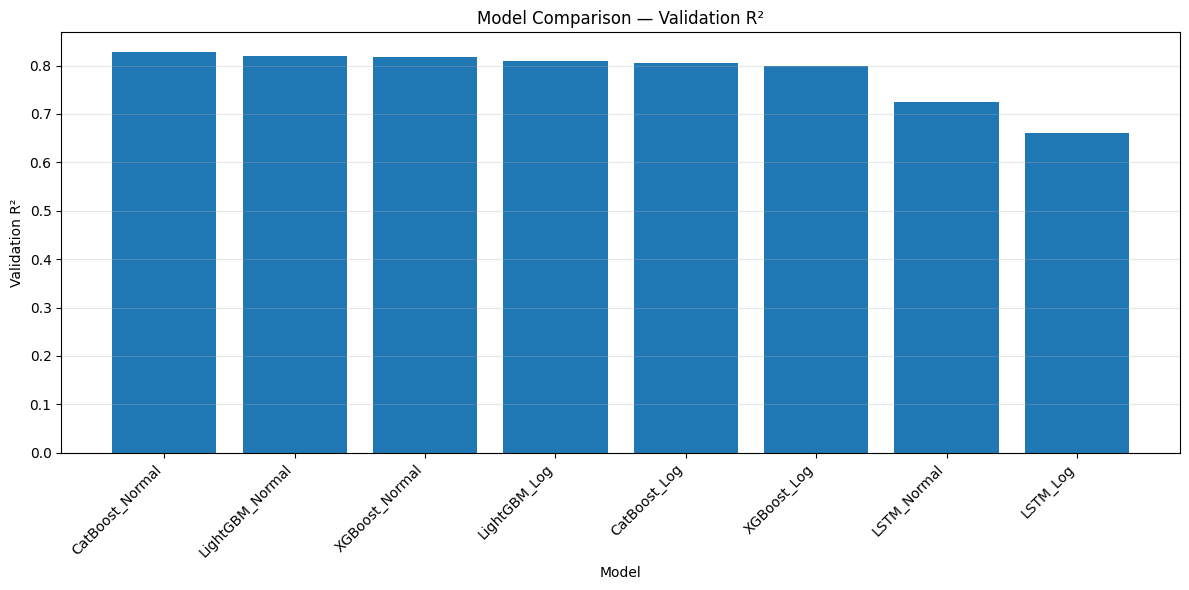

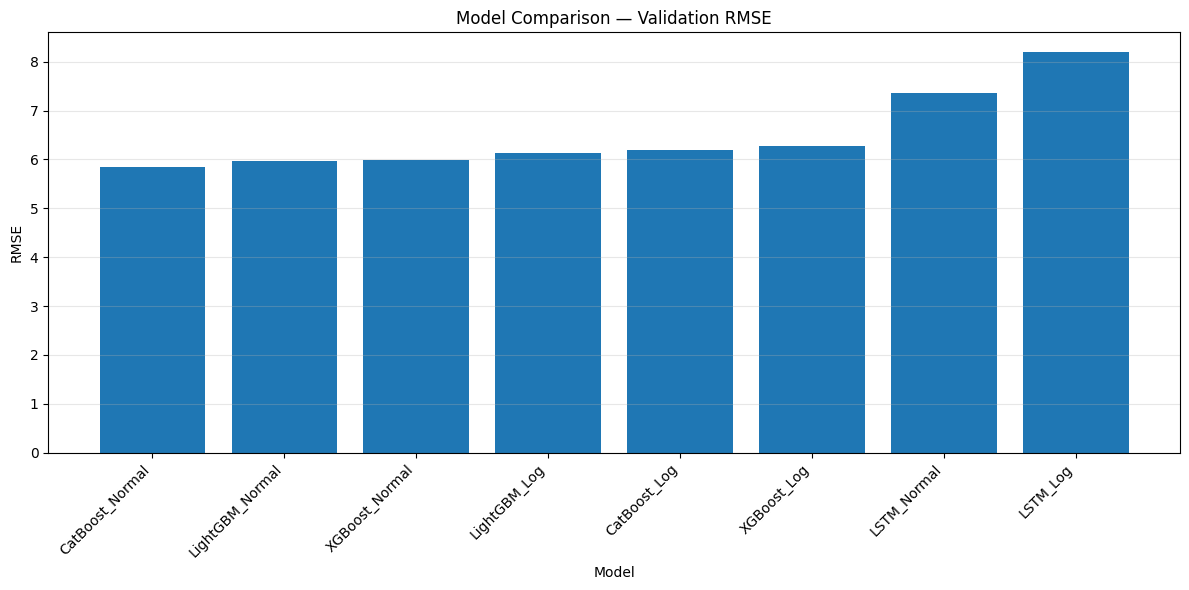

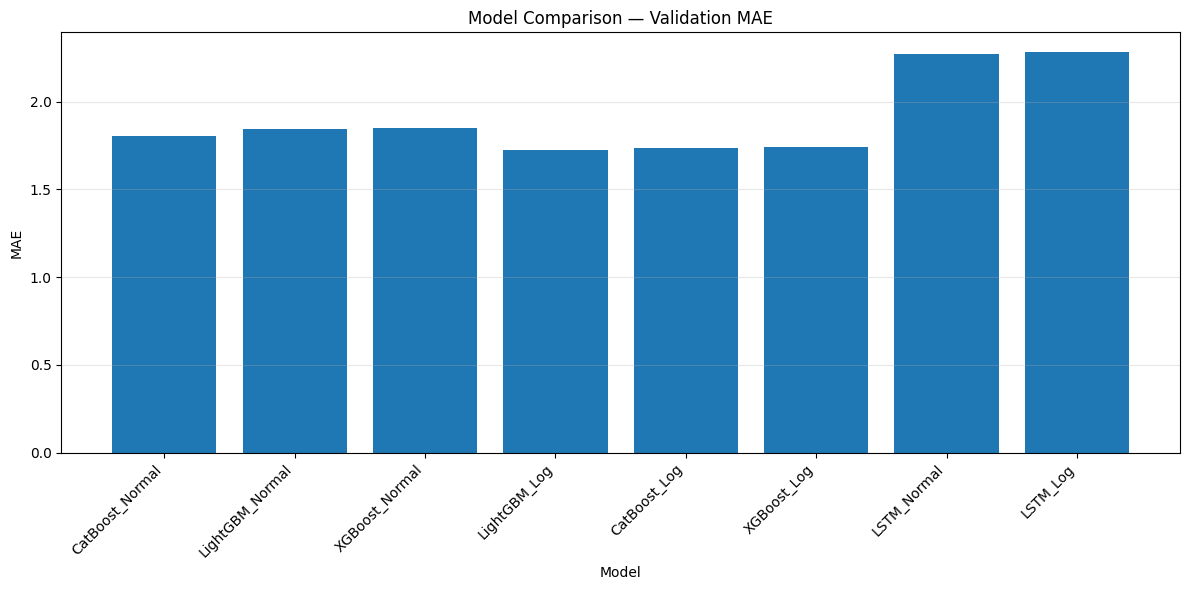

In [19]:
# MODEL ACCURACY COMPARISON

import matplotlib.pyplot as plt

comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "Validation_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 80)
print("MODEL ACCURACY COMPARISON")
print("=" * 80)

display(comparison)

# R² COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_R2"]
)

plt.xlabel("Model")
plt.ylabel("Validation R²")
plt.title("Model Comparison — Validation R²")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# RMSE COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison — Validation RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# MAE COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison — Validation MAE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

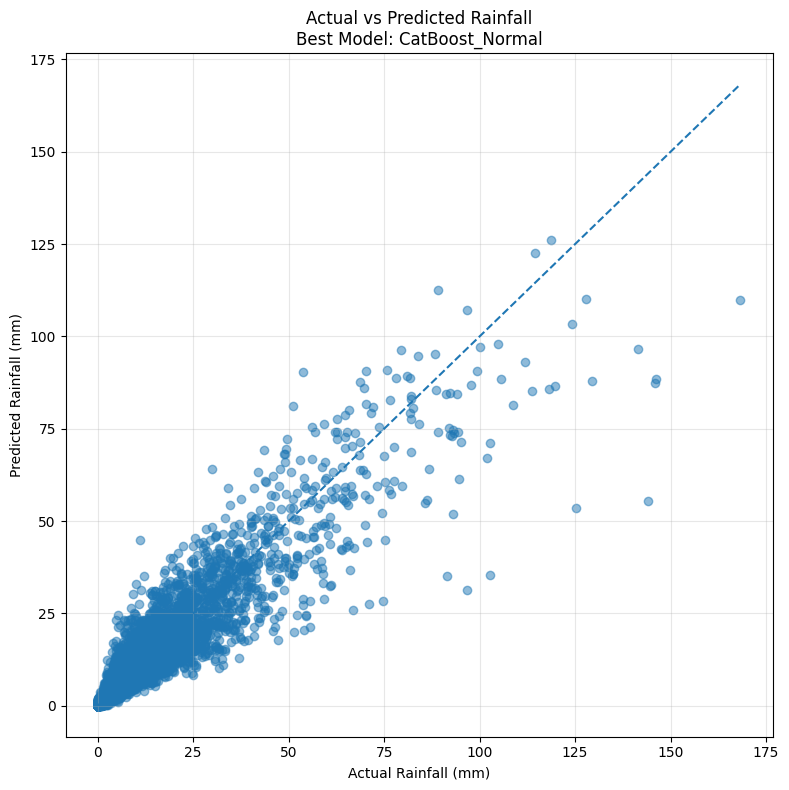

In [20]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(8, 8))

plt.scatter(
    final_y_test,
    test_pred,
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    final_y_test.min(),
    test_pred.min()
)

max_value = max(
    final_y_test.max(),
    test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")

plt.title(
    f"Actual vs Predicted Rainfall\n"
    f"Best Model: {BEST_MODEL}"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

PREDICTION PERFORMANCE ANALYSIS
Model        : CatBoost_Normal
Test samples : 12410
Test R²      : 0.8796
Test RMSE    : 4.2549 mm
Test MAE     : 1.7201 mm

Performance Summary:


,Metric,Value
0,R²,0.879588
1,RMSE (mm),4.254902
2,MAE (mm),1.720131
3,Mean Error / Bias (mm),0.027354
4,Correlation,0.937871
5,Predictions within ±1 mm,67.896857
6,Predictions within ±5 mm,90.000000
7,Predictions within ±10 mm,96.446414


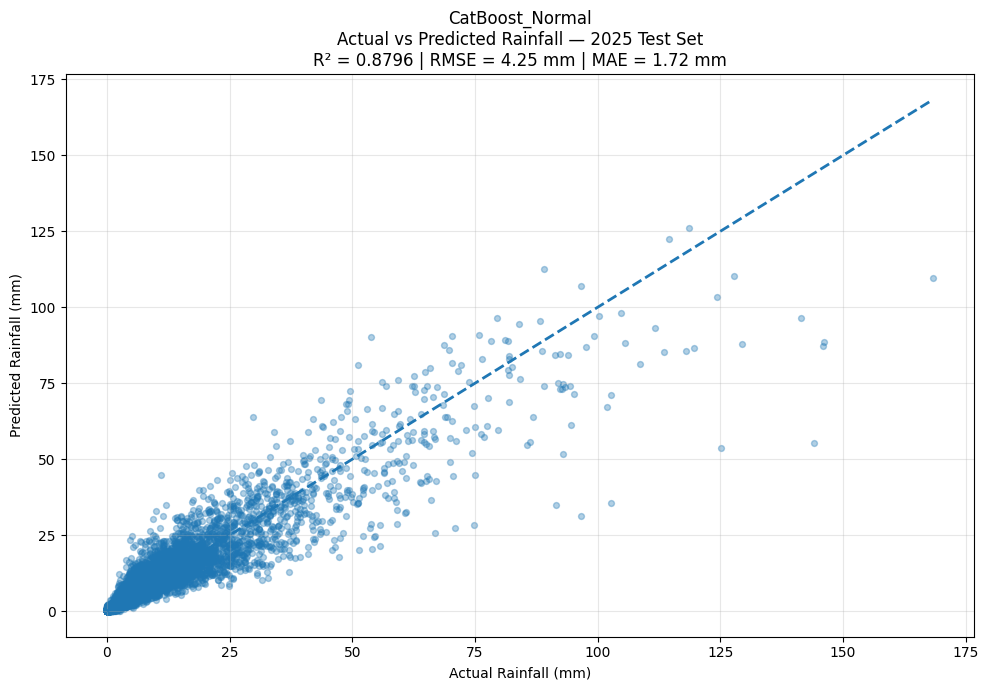

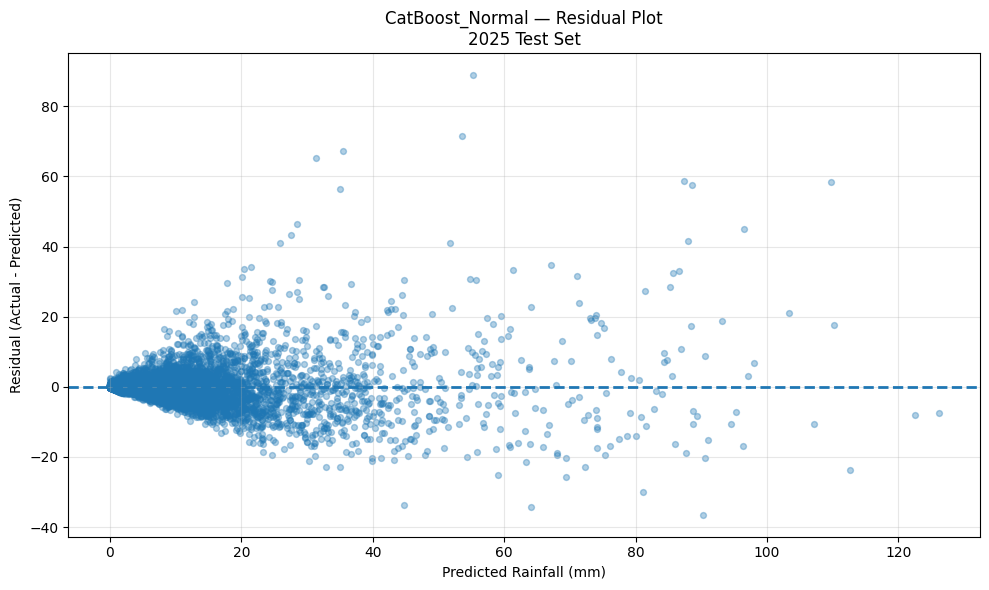

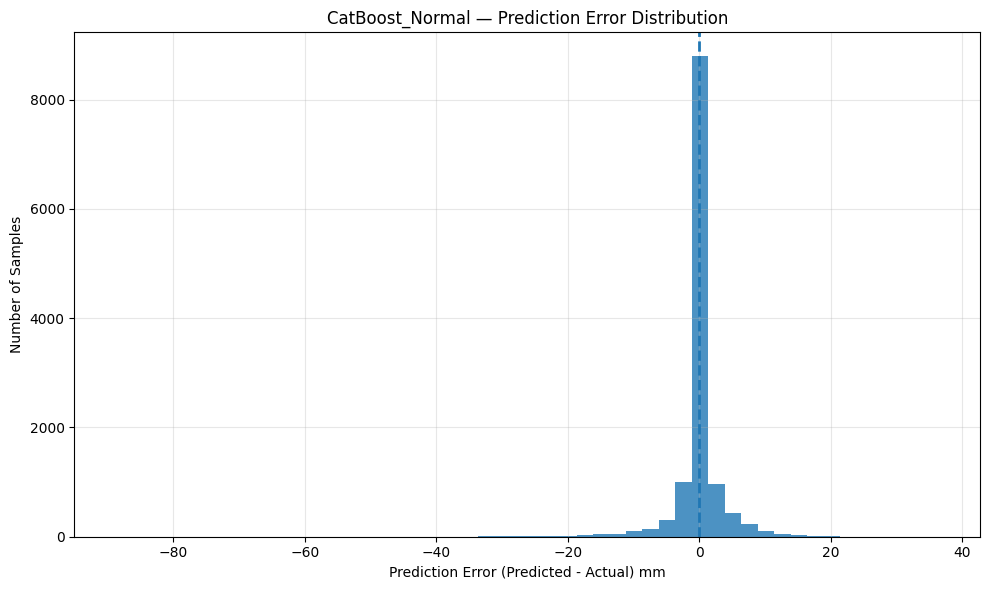


ALL MODEL VALIDATION PERFORMANCE


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,CatBoost_Normal,0.827311,5.835964,1.804154
1,LightGBM_Normal,0.818854,5.977162,1.842219
2,XGBoost_Normal,0.818538,5.982380,1.852222
3,LightGBM_Log,0.809580,6.128256,1.724083
4,CatBoost_Log,0.805127,6.199496,1.735987
5,XGBoost_Log,0.799928,6.281656,1.744450
6,LSTM_Normal,0.725309,7.360429,2.272105
7,LSTM_Log,0.659738,8.191952,2.281469


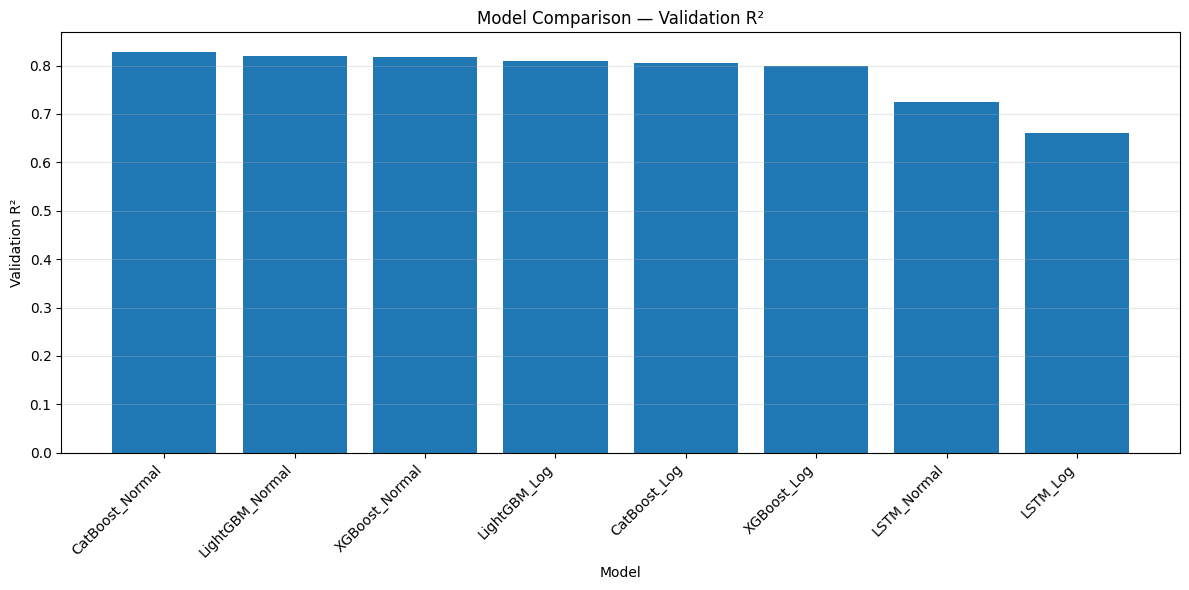

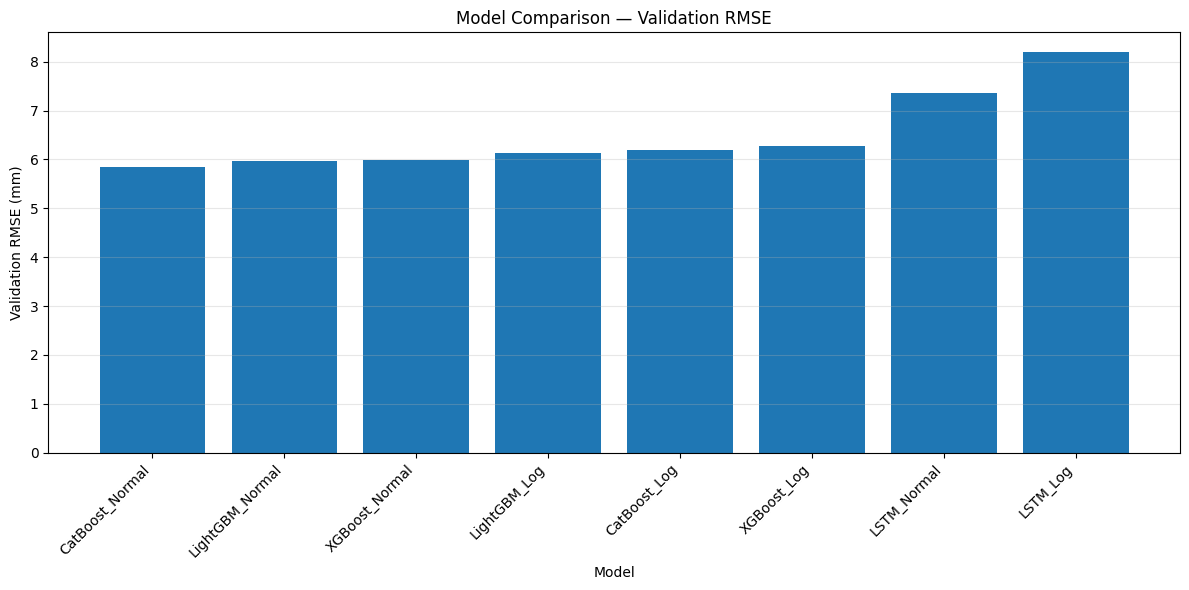

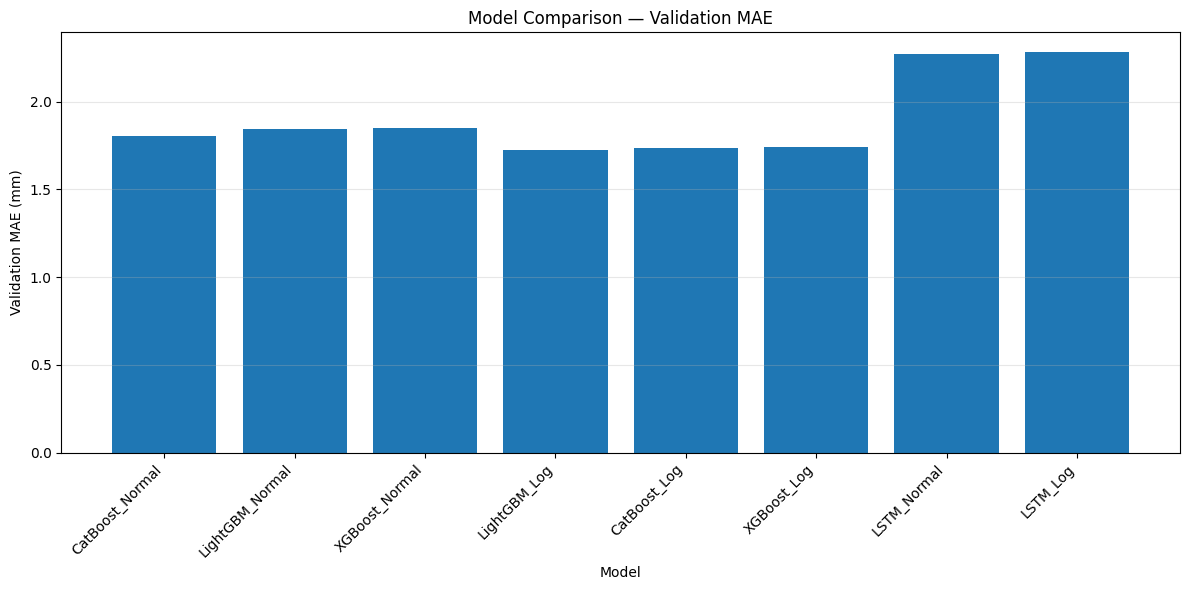


BEST MODEL
Model       : CatBoost_Normal
Validation R² : 0.8273
2025 Test R²  : 0.8796
2025 Test RMSE: 4.2549 mm
2025 Test MAE : 1.7201 mm


In [21]:
# ACTUAL vs PREDICTED + RESIDUAL ANALYSIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 1. Basic checks
actual = np.asarray(final_y_test).flatten()
predicted = np.asarray(test_pred).flatten()

print("=" * 70)
print("PREDICTION PERFORMANCE ANALYSIS")
print("=" * 70)

print(f"Model        : {BEST_MODEL}")
print(f"Test samples : {len(actual)}")
print(f"Test R²      : {test_r2:.4f}")
print(f"Test RMSE    : {test_rmse:.4f} mm")
print(f"Test MAE     : {test_mae:.4f} mm")


# 2. Additional practical metrics

errors = predicted - actual
absolute_errors = np.abs(errors)

mean_error = np.mean(errors)
correlation = np.corrcoef(actual, predicted)[0, 1]

within_1mm = np.mean(absolute_errors <= 1) * 100
within_5mm = np.mean(absolute_errors <= 5) * 100
within_10mm = np.mean(absolute_errors <= 10) * 100

performance_summary = pd.DataFrame({
    "Metric": [
        "R²",
        "RMSE (mm)",
        "MAE (mm)",
        "Mean Error / Bias (mm)",
        "Correlation",
        "Predictions within ±1 mm",
        "Predictions within ±5 mm",
        "Predictions within ±10 mm"
    ],
    "Value": [
        test_r2,
        test_rmse,
        test_mae,
        mean_error,
        correlation,
        within_1mm,
        within_5mm,
        within_10mm
    ]
})

print("\nPerformance Summary:")
display(performance_summary)


# 3. ACTUAL vs PREDICTED

plt.figure(figsize=(10, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.35,
    s=18
)

min_value = min(actual.min(), predicted.min())
max_value = max(actual.max(), predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")

plt.title(
    f"{BEST_MODEL}\n"
    f"Actual vs Predicted Rainfall — 2025 Test Set\n"
    f"R² = {test_r2:.4f} | RMSE = {test_rmse:.2f} mm | MAE = {test_mae:.2f} mm"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 4. RESIDUAL PLOT

residuals = actual - predicted

plt.figure(figsize=(10, 6))

plt.scatter(
    predicted,
    residuals,
    alpha=0.35,
    s=18
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Rainfall (mm)")
plt.ylabel("Residual (Actual - Predicted)")

plt.title(
    f"{BEST_MODEL} — Residual Plot\n"
    f"2025 Test Set"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 5. ERROR DISTRIBUTION

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=50,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Predicted - Actual) mm")
plt.ylabel("Number of Samples")

plt.title(
    f"{BEST_MODEL} — Prediction Error Distribution"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 6. MODEL COMPARISON

comparison = all_results.copy()

comparison = comparison.sort_values(
    "Validation_R2",
    ascending=False
)

print("\n" + "=" * 70)
print("ALL MODEL VALIDATION PERFORMANCE")
print("=" * 70)

display(
    comparison[
        [
            "Model",
            "Validation_R2",
            "Validation_RMSE",
            "Validation_MAE"
        ]
    ]
)


# 7. MODEL R² COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_R2"]
)

plt.ylabel("Validation R²")
plt.xlabel("Model")

plt.title("Model Comparison — Validation R²")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 8. MODEL RMSE COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_RMSE"]
)

plt.ylabel("Validation RMSE (mm)")
plt.xlabel("Model")

plt.title("Model Comparison — Validation RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 9. MODEL MAE COMPARISON

plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation_MAE"]
)

plt.ylabel("Validation MAE (mm)")
plt.xlabel("Model")

plt.title("Model Comparison — Validation MAE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Model       : {BEST_MODEL}")
print(f"Validation R² : {BEST_VAL_R2:.4f}")
print(f"2025 Test R²  : {test_r2:.4f}")
print(f"2025 Test RMSE: {test_rmse:.4f} mm")
print(f"2025 Test MAE : {test_mae:.4f} mm")
print("=" * 70)

# Tasrif's Evaluation Pass

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# Define train_pred and val_pred based on BEST_MODEL
train_pred = None
val_pred = None
current_model = trained_models[BEST_MODEL]

# Determine which X and y data to use based on model type
if BEST_MODEL.startswith("LSTM"):
    X_train_data = X_lstm_train
    y_train_data = y_lstm_train
    X_val_data = X_lstm_val
    y_val_data = y_lstm_val
else:
    X_train_data = X_train
    y_train_data = y_train
    X_val_data = X_val
    y_val_data = y_val

# Generate train_pred
if BEST_MODEL == "CatBoost_Normal":
    train_pred = current_model.predict(X_train_data)
elif BEST_MODEL == "CatBoost_Log":
    train_pred = np.expm1(current_model.predict(X_train_data))
elif BEST_MODEL == "LightGBM_Normal":
    train_pred = current_model.predict(X_train_data)
elif BEST_MODEL == "LightGBM_Log":
    train_pred = np.expm1(current_model.predict(X_train_data))
elif BEST_MODEL == "XGBoost_Normal":
    train_pred = current_model.predict(X_train_data)
elif BEST_MODEL == "XGBoost_Log":
    train_pred = np.expm1(current_model.predict(X_train_data))
elif BEST_MODEL == "LSTM_Normal":
    train_pred = current_model.predict(X_train_data, batch_size=1024, verbose=0).reshape(-1)
elif BEST_MODEL == "LSTM_Log":
    train_pred = np.expm1(current_model.predict(X_train_data, batch_size=1024, verbose=0).reshape(-1))
else:
    raise ValueError(f"Unknown model: {BEST_MODEL}")

# Generate val_pred
if BEST_MODEL == "CatBoost_Normal":
    val_pred = current_model.predict(X_val_data)
elif BEST_MODEL == "CatBoost_Log":
    val_pred = np.expm1(current_model.predict(X_val_data))
elif BEST_MODEL == "LightGBM_Normal":
    val_pred = current_model.predict(X_val_data)
elif BEST_MODEL == "LightGBM_Log":
    val_pred = np.expm1(current_model.predict(X_val_data))
elif BEST_MODEL == "XGBoost_Normal":
    val_pred = current_model.predict(X_val_data)
elif BEST_MODEL == "XGBoost_Log":
    val_pred = np.expm1(current_model.predict(X_val_data))
elif BEST_MODEL == "LSTM_Normal":
    val_pred = current_model.predict(X_val_data, batch_size=1024, verbose=0).reshape(-1)
elif BEST_MODEL == "LSTM_Log":
    val_pred = np.expm1(current_model.predict(X_val_data, batch_size=1024, verbose=0).reshape(-1))
else:
    raise ValueError(f"Unknown model: {BEST_MODEL}")

# Ensure predictions are non-negative
train_pred = np.maximum(train_pred, 0)
val_pred = np.maximum(val_pred, 0)

evaluate_model("TRAIN", y_train_data, train_pred)
evaluate_model("VALIDATION", y_val_data, val_pred)
evaluate_model("TEST", final_y_test, test_pred)


TRAIN
----------------------------------------
MAE  : 1.4454
RMSE : 3.2682
R²   : 0.9236

VALIDATION
----------------------------------------
MAE  : 1.8042
RMSE : 5.8360
R²   : 0.8273

TEST
----------------------------------------
MAE  : 1.7201
RMSE : 4.2549
R²   : 0.8796


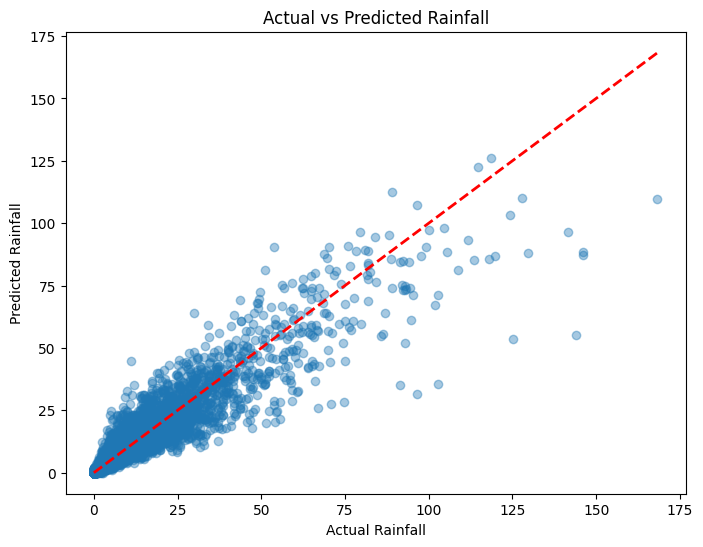

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, test_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")

plt.show()

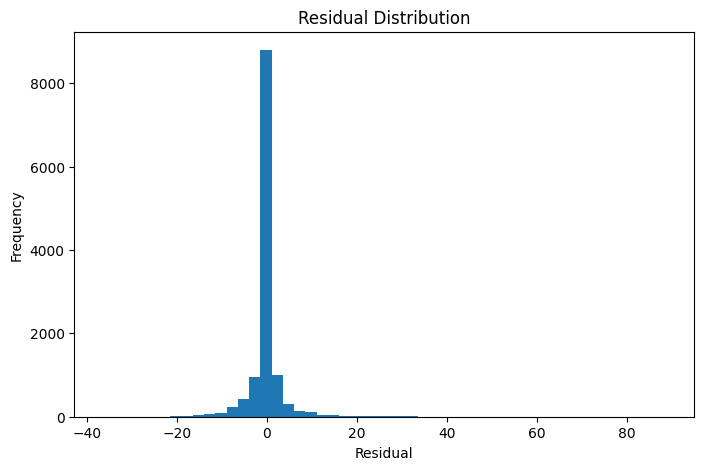

In [25]:
residuals = y_test - test_pred

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=50)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

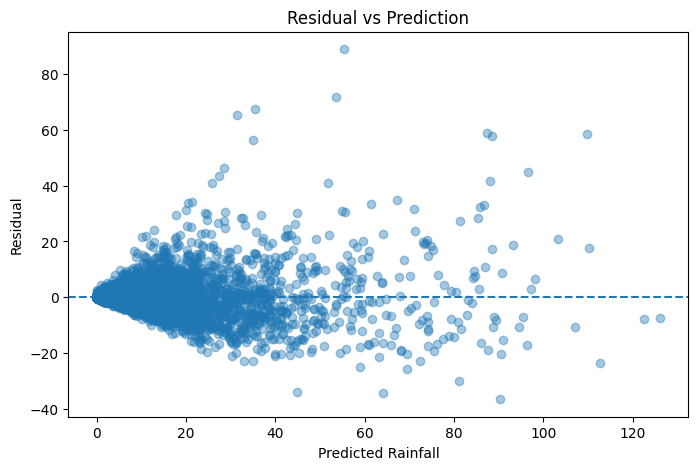

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(test_pred, residuals, alpha=0.4)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Rainfall")
plt.ylabel("Residual")

plt.title("Residual vs Prediction")

plt.show()

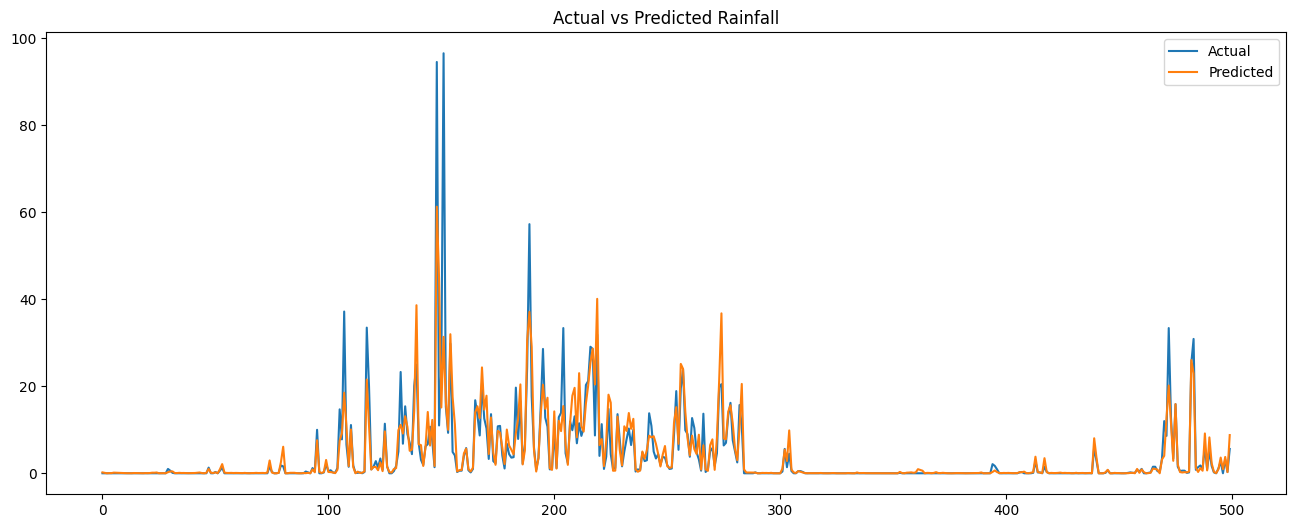

In [27]:
plt.figure(figsize=(16,6))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(test_pred[:500], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Rainfall")

plt.show()

In [28]:
heavy_mask = y_test >= 50

heavy_actual = y_test[heavy_mask]
heavy_pred = test_pred[heavy_mask]

from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("Heavy Rain Days (>50 mm)")
print("Count :", len(heavy_actual))

print(
    "MAE :",
    mean_absolute_error(heavy_actual, heavy_pred)
)

print(
    "RMSE:",
    np.sqrt(np.mean((heavy_actual-heavy_pred)**2))
)

print(
    "R² :",
    r2_score(heavy_actual, heavy_pred)
)

Heavy Rain Days (>50 mm)
Count : 199
MAE : 16.653410925049105
RMSE: 21.99044771668244
R² : 0.0012661596571653666


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": test_pred
})

comparison["Error"] = abs(
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison.sort_values(
    by="Actual",
    ascending=False
).head(20)

,Actual,Predicted,Error
65538,168.3,109.806160,58.493840
83958,146.1,88.541426,57.558574
87611,146.0,87.355331,58.644669
94846,144.1,55.315277,88.784723
39967,141.5,96.550998,44.949002
91264,129.5,87.965693,41.534307
43620,127.8,110.209646,17.590354
109436,125.2,53.607465,71.592535
36313,124.3,103.326732,20.973268
29008,119.7,86.644699,33.055301


In [32]:
import pandas as pd

current_model = trained_models[BEST_MODEL]

# Check if it's an LSTM model, for which feature importance is not directly available in this manner
if BEST_MODEL.startswith("LSTM"):
    print("Feature importance is not available for the selected LSTM model.")
elif BEST_MODEL.startswith("CatBoost"):
    importance_values = current_model.get_feature_importance()
elif BEST_MODEL.startswith("LightGBM") or BEST_MODEL.startswith("XGBoost"):
    importance_values = current_model.feature_importances_
else:
    # Fallback for any other tree-based model if added later
    raise ValueError(f"Feature importance method not defined for model type: {BEST_MODEL}")

# Only create and print importance_df if it's a tree-based model
if not BEST_MODEL.startswith("LSTM"):
    importance_df = pd.DataFrame({
        "Feature": feature_columns, # Using feature_columns for consistency and robustness
        "Importance": importance_values
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    print(importance_df.head(20))

                              Feature  Importance
0                        weather_code   37.930134
1             shortwave_radiation_sum   10.731069
2          et0_fao_evapotranspiration    7.518483
3                   sunshine_duration    4.176054
4                           Longitude    3.639663
5                          rain_lag_1    3.370013
6                  wind_gusts_10m_max    3.090634
7                  wind_speed_10m_max    2.566624
8                            Latitude    2.097384
9         wind_direction_10m_dominant    1.575267
10                 temperature_2m_max    1.112424
11                 temperature_2m_min    0.975415
12          apparent_temperature_mean    0.698464
13            daylight_duration_lag_7    0.629078
14           temperature_2m_max_lag_7    0.612601
15  wind_direction_10m_dominant_lag_1    0.596449
16                temperature_2m_mean    0.558022
17   et0_fao_evapotranspiration_lag_3    0.487185
18           wind_speed_10m_max_lag_1    0.471110


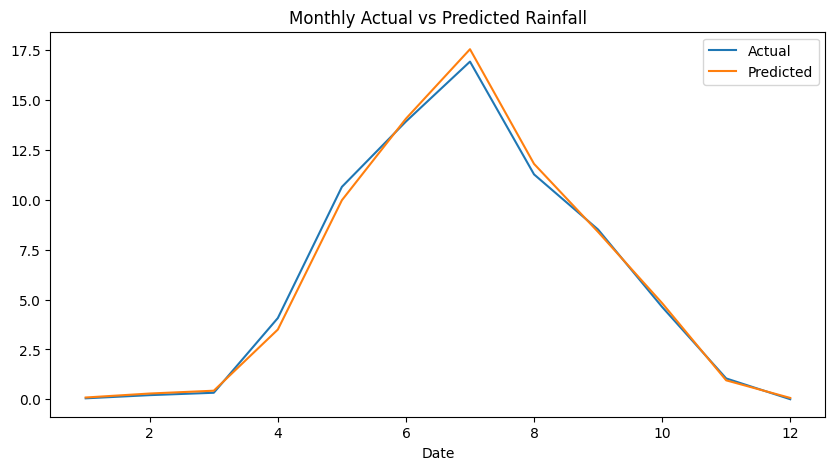

In [33]:
temp = pd.DataFrame({
    "Actual": final_y_test,
    "Predicted": test_pred
}, index=df.loc[test_mask, "Date"]) # Use the 'Date' column from df filtered by test_mask as index

monthly = temp.groupby(
    temp.index.month
).mean()

monthly.plot(
    figsize=(10,5)
)

plt.title(
    "Monthly Actual vs Predicted Rainfall"
)

plt.show()